# Step 4a -- given-background PINN (space-time neural field, fixed background)

The step-4 coordinate network `f_theta(x,y,t)` (Fourier features -> MLP), but stacked on
the **pre-calculated fixed** background of step 3a (`bdata = new_fit - new_extrafit`)
instead of a fitted PCA background. The field predicts **only the free cloud parameters**
(`n_bkg = 0`); the background is *supplied, not learned* (0 background DoF), so the
background/cloud degeneracy of step 4 cannot arise.

Any cloud parameter can be **frozen to its init** via `FREEZE` (default `log a`), so the
head width is flexible: `n_out = n_bkg + n_free`. Everything else -- Fourier smoothness
knobs `SIGMA_XY`/`SIGMA_T`, range transforms, loss, training -- is exactly step 4.
Config-driven and laptop-scale; raise the sizes / set CUDA to deploy on the server.

In [1]:
import sys, os
sys.path.insert(0, '..')          # cloud_model_torch.py / utils.py (repo root)

import time
import numpy as np
import torch
import matplotlib.pyplot as plt

from pinn_model import ParameterField, grid_coords
from composite_model import composite_synth_given, chi2_per_pixel
from given_background import load_given_background_window, default_bkg_path

%load_ext autoreload
%autoreload 2

In [ ]:
# ---- configuration: compact, laptop-scale given-background PINN ----
N_BASIS = 10       # trailing snapshots used only to define Iqs (matches step 3/4)
LAM     = slice(100, 500)

# fit window
T0   = 13
N_T  = 3           # frames -> exercises temporal regularisation
CROP = 64          # 64 x 64 spatial crop

# which cloud parameters to FREEZE (held at their init everywhere). Default: log a.
# Freeze more to hold e.g. a velocity fixed:  FREEZE = ("loga1", "loga2", "vlos1")
FREEZE = ("loga1", "loga2")

# neural field (same knobs as step 4; the sigmas are the space/time smoothness regulariser)
N_FREQ   = 128
SIGMA_XY = 16.0     # spatial Fourier bandwidth  (smaller = smoother)
SIGMA_T  = 2.0     # temporal Fourier bandwidth
WIDTH    = 256
DEPTH    = 4
S_MAX    = 0.7     # S in [0, S_MAX]
DV_FLOOR = 8.0     # dv >= DV_FLOOR (km/s), the ~thermal floor

# training (cosine-annealed Adam)
N_ITERS   = 1200
LR        = 5e-3
GRAD_CLIP = 1.0
BATCH     = None   # None = full batch; int = minibatch over coordinates

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
_CANDS = ['/dat/milic/MiHI_filament/mihi_all_data.npz',
          '/home/milic/data/MiHI_halpha_filament/mihi_all_data.npz']
DATA_NPZ = next((p for p in _CANDS if os.path.exists(p)), _CANDS[0])
BKG_NPZ  = default_bkg_path(DATA_NPZ)   # given background lives next to the data cube
device   = torch.device(DEVICE)
print("device:", device, "| data:", DATA_NPZ)
print("bkg  :", BKG_NPZ)

device: cuda | data: /dat/milic/MiHI_filament/mihi_all_data.npz
bkg  : /dat/milic/MiHI_filament/mihi_rvm_reconstruction_averages_skglm.npz


In [11]:
# ---- load cube once; carve the fit window; load the SAME-window given background ----
f    = np.load(DATA_NPZ, allow_pickle=True)
wav  = np.asarray(f['wav'])
cube = f['data']                                             # (t, y, x, lambda)

YS, XS = slice(15, -15), slice(15, -15)
blk = np.copy(cube[-N_BASIS:, YS, XS, LAM]).astype(np.float32)
Iqs = float(blk[..., -20:].mean())

full   = cube[:, YS, XS, LAM]
Ny, Nx = full.shape[1], full.shape[2]
cy, cx = Ny // 2, Nx // 2
ys = slice(cy - CROP // 2, cy - CROP // 2 + CROP)
xs = slice(cx - CROP // 2, cx - CROP // 2 + CROP)
ts = list(range(T0 - N_T // 2, T0 - N_T // 2 + N_T))
obs = np.copy(full[ts][:, ys, xs, :]).astype(np.float32) / Iqs
del f, cube, full

Nt, Cy, Cx, L = obs.shape
xl  = [np.copy(wav[LAM]).astype(np.float32), np.asarray([np.mean(wav[LAM])], dtype=np.float32)]

obs_pt = torch.from_numpy(obs.reshape(-1, L)).to(device)
coords = grid_coords(Nt, Cy, Cx, device=device)

# fixed given background bdata=(new_fit-new_extrafit)/Iqs, carved to the SAME window
# (same YS/XS/LAM crop, same ys/xs crop, same frames ts, same Iqs) -> rows match obs_pt.
I_in, bshape = load_given_background_window(BKG_NPZ, ts, YS, XS, LAM, ys, xs, Iqs, device=device)
assert I_in.shape == obs_pt.shape, (I_in.shape, obs_pt.shape)
assert not I_in.requires_grad, "given background must carry NO free parameters"
print("frames:", ts, "| crop:", (Cy, Cx), "| N samples:", coords.shape[0], "| L:", L)
print("I_in:", tuple(I_in.shape), "| bg free params: 0 | mean=%.4f" % float(I_in.mean()))

frames: [12, 13, 14] | crop: (64, 64) | N samples: 12288 | L: 400
I_in: (12288, 400) | bg free params: 0 | mean=0.6837


In [12]:
# ---- neural field: predicts the FREE cloud params only (n_bkg=0, given background) ----
field = ParameterField(d_in=3, n_freq=N_FREQ, sigmas=(SIGMA_XY, SIGMA_XY, SIGMA_T),
                       width=WIDTH, depth=DEPTH, s_max=S_MAX, dv_floor=DV_FLOOR,
                       n_bkg=0, freeze=FREEZE).to(device)
n_free = field.head.out_features - field.n_bkg
print("frozen:", FREEZE, "| n_free:", n_free, "| head out:", field.head.out_features,
      "| n_bkg:", field.n_bkg, "| field weights:", sum(p.numel() for p in field.parameters()))

with torch.no_grad():
    _, pc0 = field(coords)
    syn0   = composite_synth_given(xl, I_in, pc0, loga_clamp=None)
    _, l0  = chi2_per_pixel(obs_pt, syn0, reduce_mean=True)
print("init cloud means [S1,tau1,v1,dv1,loga1,S2,tau2,v2,dv2,loga2]:",
      pc0.mean(0).cpu().numpy().round(2))
print("initial loss:", round(float(l0), 4), "| all finite:", bool(torch.isfinite(syn0).all()))

frozen: ('loga1', 'loga2') | n_free: 8 | head out: 8 | n_bkg: 0 | field weights: 265224
init cloud means [S1,tau1,v1,dv1,loga1,S2,tau2,v2,dv2,loga2]: [  0.2   4.5 -20.   12.   -4.    0.6   4.5  20.   12.   -5. ]
initial loss: 6.4952 | all finite: True


In [13]:
# ---- gradient check: loss -> network weights; frozen slots carry NO gradient ----
for p in field.parameters():
    p.grad = None
_, pc = field(coords)
_, loss = chi2_per_pixel(obs_pt, composite_synth_given(xl, I_in, pc, loga_clamp=None), reduce_mean=True)
loss.backward()
names  = ['S1','dtau1','vlos1','dv1','loga1','S2','dtau2','vlos2','dv2','loga2']
col    = {n: i for i, n in enumerate(names)}
n_grad = sum(int(p.grad is not None) for p in field.parameters())
gnorm  = sum(float(p.grad.norm()) for p in field.parameters() if p.grad is not None)
# frozen cloud columns must be constant across all coords (inserted init, no grad path)
frozen_const = all(bool((pc[:, col[n]] == pc[0, col[n]]).all()) for n in FREEZE)
print("params with grad: %d / %d | total grad norm: %.4f"
      % (n_grad, sum(1 for _ in field.parameters()), gnorm))
print("frozen slots", FREEZE, "constant across field:", frozen_const)

params with grad: 10 / 10 | total grad norm: 6.2103
frozen slots ('loga1', 'loga2') constant across field: True


  0%|          | 0/1200 [00:00<?, ?it/s]

loss 6.4952e+00 -> 1.9119e-01 | 12.5 s, 10.4 ms/iter (12288 samples/iter)


Text(0.5, 1.0, 'given-background PINN loss')

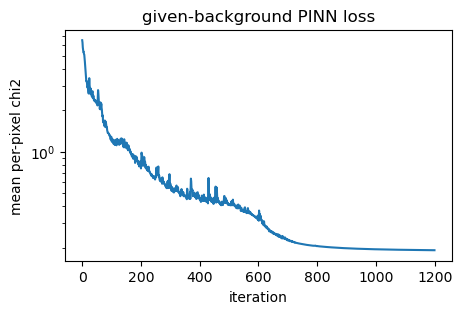

In [14]:
# ---- train (cosine-annealed Adam, grad clip, timed) ----
from tqdm.auto import trange
from torch.optim.lr_scheduler import CosineAnnealingLR
opt   = torch.optim.Adam(field.parameters(), lr=LR)
sched = CosineAnnealingLR(opt, T_max=N_ITERS, eta_min=LR * 0.05)
hist  = []
n     = coords.shape[0]
t_start = time.time()
for it in trange(N_ITERS):
    opt.zero_grad()
    if BATCH is None:
        cb, ob, ib = coords, obs_pt, I_in
    else:
        idx = torch.randint(0, n, (BATCH,), device=device)
        cb, ob, ib = coords[idx], obs_pt[idx], I_in[idx]
    _, pc = field(cb)
    _, loss = chi2_per_pixel(ob, composite_synth_given(xl, ib, pc, loga_clamp=None), reduce_mean=True)
    if not torch.isfinite(loss):
        print("non-finite loss at iter", it, "-- stopping"); break
    loss.backward()
    torch.nn.utils.clip_grad_norm_(field.parameters(), GRAD_CLIP)
    opt.step(); sched.step(); hist.append(float(loss))
dt = time.time() - t_start; ms = 1e3 * dt / max(len(hist), 1)
print("loss %.4e -> %.4e | %.1f s, %.1f ms/iter (%d samples/iter)"
      % (hist[0], hist[-1], dt, ms, n if BATCH is None else BATCH))
plt.figure(figsize=(5, 3)); plt.semilogy(hist)
plt.xlabel('iteration'); plt.ylabel('mean per-pixel chi2'); plt.title('given-background PINN loss')

In [17]:
# ---- QUANTITATIVE SUMMARY (quickest read of the fit) ----
with torch.no_grad():
    _, p_all = field(coords)
    syn = composite_synth_given(xl, I_in, p_all, loga_clamp=None)
resid   = obs_pt - syn
chi2v   = (resid ** 2).sum(-1)
rms_pct = 100.0 * float(torch.sqrt((resid ** 2).mean())) / float(obs_pt.mean())
print("final mean per-pixel chi2: %.4f | median: %.4f | p95: %.4f"
      % (float(chi2v.mean()), float(chi2v.median()), float(torch.quantile(chi2v, 0.95))))
print("RMS residual: %.2f %% of mean intensity" % rms_pct)
pa = p_all.cpu().numpy()
print("\n  param      min    median      max")
for j, nm in enumerate(names):
    print("  %-7s %8.3f %8.3f %8.3f" % (nm, pa[:, j].min(), np.median(pa[:, j]), pa[:, j].max()))
core = L // 2
oco  = float(obs_pt[:, core-20:core+20].mean()); ico = float(I_in[:, core-20:core+20].mean())
print("\ncore (idx %d): obs=%.4f  I_in=%.4f  -> I_in above observed core: %s"
      % (core, oco, ico, ico > oco))

final mean per-pixel chi2: 0.1912 | median: 0.1616 | p95: 0.3481
RMS residual: 3.45 % of mean intensity

  param      min    median      max
  S1         0.003    0.163    0.672
  dtau1      0.008    0.692   10.049
  vlos1   -127.959  -26.092   43.549
  dv1        8.333   21.497   67.752
  loga1     -4.000   -4.000   -4.000
  S2         0.062    0.195    0.520
  dtau2      0.000    0.747    4.027
  vlos2    -29.762   -8.958   28.539
  dv2        8.525   12.335   25.772
  loga2     -5.000   -5.000   -5.000

core (idx 200): obs=0.2758  I_in=0.3050  -> I_in above observed core: True


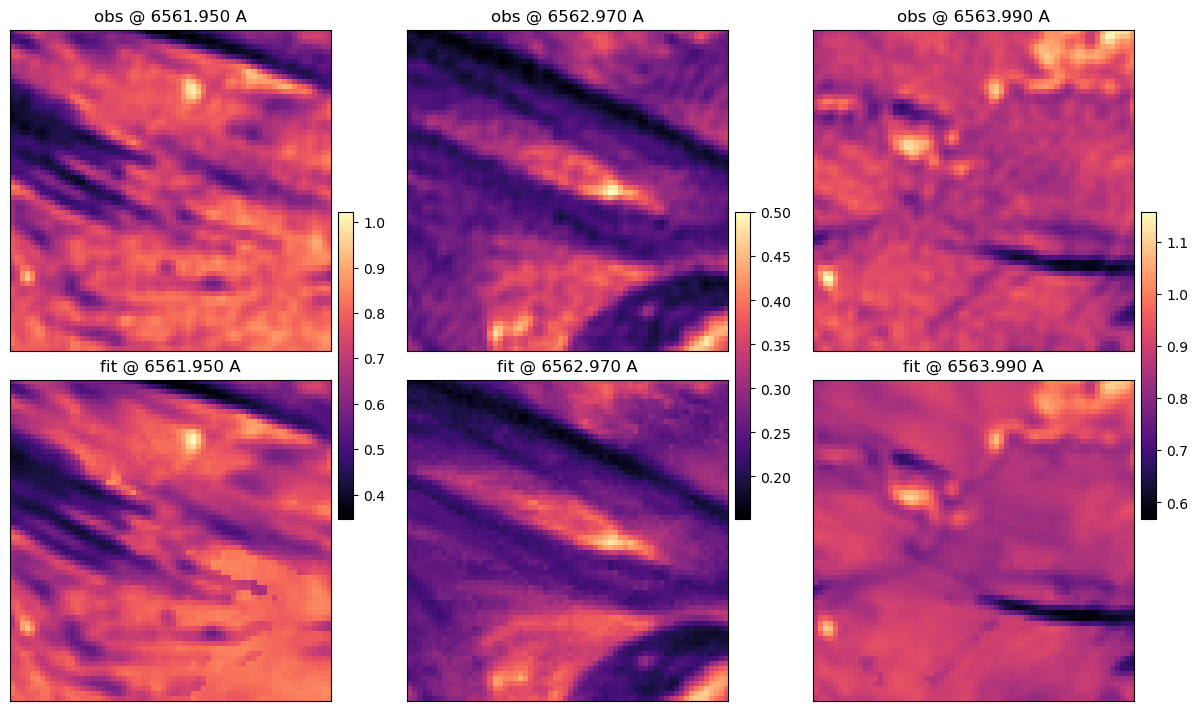

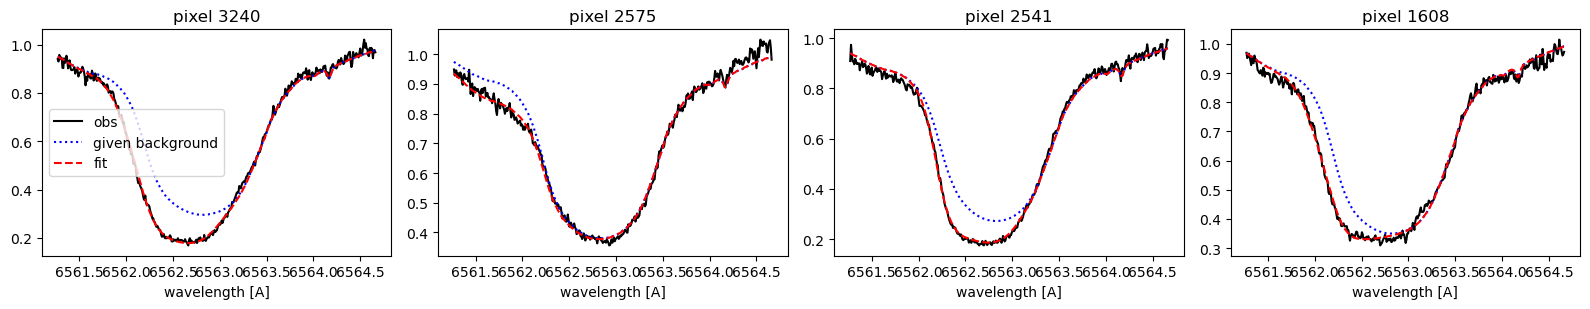

In [18]:
# ---- obs vs fit image maps (centre frame) + a few pixel spectra; save a PDF ----
os.makedirs('../figs', exist_ok=True)
kf = Nt // 2; core = L // 2; wl = wav[LAM]
oc = obs_pt.cpu().numpy().reshape(Nt, Cy, Cx, L)[kf]
fc = syn.cpu().numpy().reshape(Nt, Cy, Cx, L)[kf]
bc = I_in.cpu().numpy().reshape(Nt, Cy, Cx, L)[kf]
wl_idx = [max(core - 120, 0), core, min(core + 120, L - 1)]

fig, ax = plt.subplots(2, 3, figsize=(12, 7), constrained_layout=True)
for j, ii in enumerate(wl_idx):
    vmn = min(oc[:, :, ii].min(), fc[:, :, ii].min()); vmx = max(oc[:, :, ii].max(), fc[:, :, ii].max())
    ax[0, j].imshow(oc[:, :, ii].T, origin='lower', cmap='magma', vmin=vmn, vmax=vmx)
    im = ax[1, j].imshow(fc[:, :, ii].T, origin='lower', cmap='magma', vmin=vmn, vmax=vmx)
    ax[0, j].set_title('obs @ %.3f A' % wl[ii]); ax[1, j].set_title('fit @ %.3f A' % wl[ii])
    for a in (ax[0, j], ax[1, j]):
        a.set_xticks([]); a.set_yticks([])
    fig.colorbar(im, ax=[ax[0, j], ax[1, j]], fraction=0.046, pad=0.02)
plt.savefig('../figs/step_4a_pinn_fit_images.pdf', dpi=200)

o2, f2, b2 = oc.reshape(-1, L), fc.reshape(-1, L), bc.reshape(-1, L)
np.random.seed(2); ii = np.random.randint(0, Cy * Cx, size=4)
fig, ax = plt.subplots(1, 4, figsize=(16, 3.2))
for j, p in enumerate(ii):
    ax[j].plot(wl, o2[p], 'k',  label='obs')
    ax[j].plot(wl, b2[p], 'b:', label='given background')
    ax[j].plot(wl, f2[p], 'r--', label='fit')
    ax[j].set_title('pixel %d' % p); ax[j].set_xlabel('wavelength [A]')
ax[0].legend(); plt.tight_layout()

In [ ]:
# ---- comprehensive cloud-parameter maps (centre frame), robust colour limits ----
# All 8 FREE cloud parameters as spatial images. Colour limits are the 2-98th
# percentile so a few runaway pixels do not wash out the map (full ranges are in
# the summary above); velocities use a symmetric diverging scale about 0.
kf = Nt // 2
pm = p_all.cpu().numpy().reshape(Nt, Cy, Cx, 10)[kf]
specs = [('S1', 0, 'viridis'), ('dtau1', 1, 'viridis'), ('vlos1', 2, 'seismic'), ('dv1', 3, 'magma'),
         ('S2', 5, 'viridis'), ('dtau2', 6, 'viridis'), ('vlos2', 7, 'seismic'), ('dv2', 8, 'magma')]
fig, ax = plt.subplots(2, 4, figsize=(18, 8), constrained_layout=True); ax = ax.ravel()
for k, (nm, j, cmap) in enumerate(specs):
    im2 = pm[:, :, j].T
    lo, hi = np.percentile(im2, [2, 98])
    if cmap == 'seismic':                      # symmetric about 0 for a signed velocity
        m = max(abs(lo), abs(hi)); lo, hi = -m, m
    h = ax[k].imshow(im2, origin='lower', cmap=cmap, vmin=lo, vmax=hi)
    ax[k].set_title('%s   [%.2f, %.2f] (2-98%%)' % (nm, lo, hi))
    ax[k].set_xticks([]); ax[k].set_yticks([])
    fig.colorbar(h, ax=ax[k], fraction=0.046, pad=0.02)
fig.suptitle('cloud parameter maps, frame %d   (log a frozen; full min/med/max above)' % ts[kf])
plt.savefig('../figs/step_4a_pinn_param_maps.pdf', dpi=150)

In [ ]:
# ---- DIAGNOSTIC: off the core the model reverts to the FIXED given background ----
# The two clouds impose opacity only near their (Doppler-shifted) velocities; far from
# there I_out -> I_in, so the wings are set by the fixed background, not the clouds.
obsn, synn, iinn = obs_pt.cpu().numpy(), syn.cpu().numpy(), I_in.cpu().numpy()
rms_fit = np.sqrt(((obsn - synn) ** 2).mean(0))            # (L,) obs vs fit
rms_bkg = np.sqrt(((obsn - iinn) ** 2).mean(0))            # (L,) obs vs background (no clouds)
wl = wav[LAM]; core = L // 2
# how far the clouds can move the background: fractional absorption for the MEDIAN params
p_med = torch.from_numpy(np.median(p_all.cpu().numpy(), 0, keepdims=True)).to(obs_pt.device)
reach = np.abs(1.0 - composite_synth_given(
    xl, torch.ones(1, L, device=obs_pt.device), p_med, loga_clamp=None).detach().cpu().numpy()[0])

fig, ax = plt.subplots(1, 3, figsize=(18, 4), constrained_layout=True)
ax[0].semilogy(wl, rms_fit, 'r', label='obs - fit')
ax[0].semilogy(wl, rms_bkg, 'b:', label='obs - given background')
ax[0].axvline(wl[core], color='k', lw=0.6); ax[0].legend()
ax[0].set_xlabel('wavelength [A]'); ax[0].set_ylabel('field RMS')
ax[0].set_title('clouds cut the residual ONLY near the core')
ax[1].plot(wl, reach, 'g'); ax[1].axvline(wl[core], color='k', lw=0.6)
ax[1].axhline(0.02, color='0.6', ls=':')
ax[1].set_xlabel('wavelength [A]'); ax[1].set_ylabel('|1 - I_out/I_in|  (median params)')
ax[1].set_title('cloud reach ~0 in the wings -> fit = fixed background there')
# spatial residual |obs-fit| at the red wing -- where the clouds cannot reach
kf = Nt // 2; rr = np.abs(obsn - synn).reshape(Nt, Cy, Cx, L)[kf]
im3 = ax[2].imshow(rr[:, :, min(core+120, L-1)].T, origin='lower', cmap='inferno')
ax[2].set_title('|obs - fit| @ red wing %.3f A' % wl[min(core+120, L-1)])
ax[2].set_xticks([]); ax[2].set_yticks([]); fig.colorbar(im3, ax=ax[2], fraction=0.046, pad=0.02)

wing = reach < 0.02
print("WINGS (|cloud reach|<2%%): obs-fit RMS %.4f  vs  obs-background RMS %.4f  (nearly equal:"
      " the clouds can't help here)" % (rms_fit[wing].mean(), rms_bkg[wing].mean()))
print("CORE (idx %d):            obs-fit RMS %.4f  vs  obs-background RMS %.4f  (clouds do the work)"
      % (core, rms_fit[core], rms_bkg[core]))
print("=> off-core fidelity is capped by the FIXED given background; the smooth skglm "
      "reconstruction lacks the fine wing texture, so the wing maps look washed out.")

## Notes

- **Given background = 0 DoF.** `I_in` is fixed; the field solves only the free cloud
  parameters, so the step-4 background/cloud degeneracy cannot arise (no `no_emission`
  cap / `background_anchor` needed). `I_in` should sit **above** the observed core -- the
  two clouds supply the absorption.
- **Freeze any parameter.** `FREEZE` names slots from
  `[S,dtau,vlos,dv,loga] x 2`; a frozen slot is held at its init everywhere and drops out
  of the head (`n_out = n_bkg + n_free`). Default freezes `log a`; add e.g. `"vlos1"` to
  pin a velocity. Use `init={...}` on `ParameterField` to choose the frozen value.
- **Regularisation knobs:** lower `SIGMA_XY`/`SIGMA_T` for smoother maps, raise for detail.
- **Assess & persist:** the *quantitative summary* is the quickest read; then the maps and
  spectra. Run all cells and **save the notebook** so outputs persist.
- **Scale to the server:** raise `CROP`/`N_T`/`WIDTH`/`DEPTH`/`N_FREQ`, set `BATCH` if
  memory-bound, `device=cuda`. Same code -- the given background is memory-mapped, so only
  the fit-window frames are paged in.
- **Off-core fit is background-limited (by design).** The clouds impose opacity only near their velocities, so far from the core `I_out -> I_in`: the wings are set by the *fixed* given background. The diagnostic cell shows `obs-fit` RMS ~= `obs-background` RMS in the wings (clouds can't help) but `obs-fit` << `obs-background` at the core. The skglm background is smooth, so fine wing texture is not reproduced -- expected for the given-background mode. Runaway `vlos1`/`dv1` tails are pixels contorting a cloud to reach off-core structure; cap them (bounded `vlos`, `dv`) or core-weight the loss if it matters.
